In [2]:
import torch
from accelerate import Accelerator
from torch.utils.data import DataLoader
from torchvision import transforms as tf
from torchvision.datasets import FashionMNIST
from torchvision.utils import make_grid, save_image
from torch_ema import ExponentialMovingAverage as EMA
from tqdm import tqdm
from IPython.display import display
import matplotlib.pyplot as plt
from pathlib import Path

from smalldiffusion import (
    ScheduleLogLinear, samples, training_loop, MappedDataset, Unet, Scaled,
    img_train_transform, img_normalize
)

from dataset import LatentAudioDataset, decode_audio, load_model as load_audio_codec


c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_batch_size = 4
sample_batch_size = 2
epochs = 30

EMBEDDINGS_PATH = Path("C:/Users/dzluk/stable-audio-tools/data/blackbird/embeddings")

# for now, trim the inputs from [1, 64, 1024] to [1, 64, 64] so they are square
data_transform = tf.Compose([
    tf.Lambda(lambda x: x[:, :, :64]),
])

dataset = LatentAudioDataset(EMBEDDINGS_PATH, normalize=False, transform=data_transform)

# Setup
a = Accelerator()
loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)
schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=20, N=800)
model = Scaled(Unet)(in_dim=64, in_ch=1, out_ch=1, ch=128, ch_mult=(1, 1, 2), attn_resolutions=(14,))

In [ ]:
# # Load pre-trained model (optional - skip to Train cell to train from scratch)
# checkpoint_path = 'fashion-checkpoint.pth'

# import os
# if os.path.exists(checkpoint_path):
#     model.load_state_dict(torch.load(checkpoint_path, map_location=a.device))
#     print(f"Loaded model from {checkpoint_path}")
# else:
#     print(f"No checkpoint found at {checkpoint_path}, you should train from scratch")

Loss=0.76206: 100%|██████████| 30/30 [02:38<00:00,  5.27s/it]  


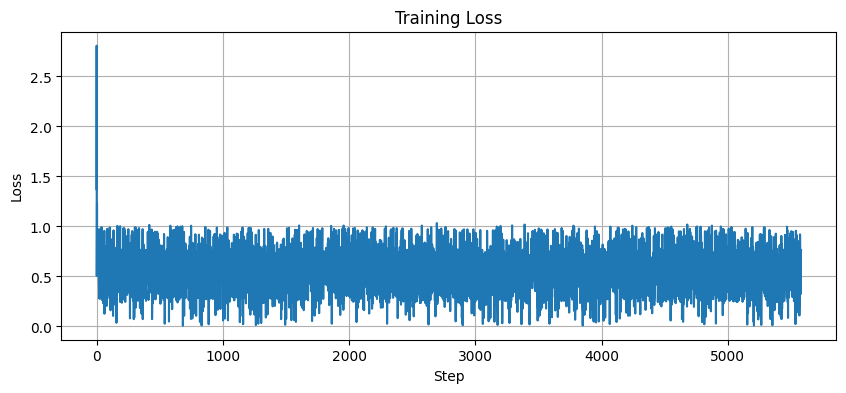

In [4]:
# Train
losses = []
ema = EMA(model.parameters(), decay=0.999)
ema.to(a.device)
for ns in training_loop(loader, model, schedule, epochs=epochs, lr=7e-4, accelerator=a):
    losses.append(ns.loss.item())
    ns.pbar.set_description(f'Loss={ns.loss.item():.5}')
    ema.update()

# Save checkpoint
torch.save(model.state_dict(), 'fashion-checkpoint.pth')

# Plot training losses
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [ ]:
# Sample
with ema.average_parameters():
    *xt, x0 = samples(model, schedule.sample_sigmas(20), gam=1.6,
                        batchsize=sample_batch_size, accelerator=a)
    grid = img_normalize(make_grid(x0))
    
# Display in notebook
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Generated Fashion MNIST Samples')
plt.show()

In [8]:
test = torch.ones((1,64,1024))

In [ ]:
test.shape

torch.Size([1, 64, 64])